In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings  # See this package for the Goland wing structural and aerodynamic definition
import sharpy.sharpy_main  # used to run SHARPy from Jupyter


In [26]:
u_inf = 1.
alpha_deg = 2.  # Define angle of attack for static aeroelastic analysis.
rho = 1.02      # Air density.

In [27]:
M = 16             # Number of chordwise panels
N = 32             # Number of spanwise panels
M_star_fact = 10   # Length of the wake in chords.
num_modes =  8     # Number of vibration modes retained in the structural model.

In [28]:
c_ref = .125 
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

In [29]:
case_name = 'try2'
case_nlin_info = 'M%dN%dMs%d_nmodes%d' % (M, N, M_star_fact, num_modes)
case_rom_info = 'rom_MIMORA_r%d_sig%04d_%04dj' % (rom_settings['r'], frequency_continuous_k[-1].real * 100,
                                                  frequency_continuous_k[-1].imag * 100)

case_name += case_nlin_info + case_rom_info
route_test_dir = os.path.abspath('')

print('The case to run will be: %s' % case_name)
print('Case files will be saved in ./cases/%s' %case_name)
print('Output files will be saved in ./output/%s/' %case_name)

The case to run will be: try2M16N32Ms10_nmodes8rom_MIMORA_r6_sig0000_0000j
Case files will be saved in ./cases/try2M16N32Ms10_nmodes8rom_MIMORA_r6_sig0000_0000j
Output files will be saved in ./output/try2M16N32Ms10_nmodes8rom_MIMORA_r6_sig0000_0000j/


In [30]:
chord = .125
b_ref = 2*.75

ws = wings.Pazy(M=M,
                N=N,
                Mstar_fact=M_star_fact,
                u_inf=u_inf,
                alpha=alpha_deg,
                tip_rod=False,
                rho=rho,
                b_ref=b_ref,
                main_chord=chord,
                aspect_ratio = b_ref/chord,
                sweep=0,
                physical_time=2,
                n_surfaces=2,
                route=route_test_dir + '/cases',
                case_name=case_name)



def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra
    self.main_ea = .525 
    self.main_cg = 0.48
    #beam
    thickness = 0.003 #meters
    length = 0.75 #meters
    width = 0.095 #meters
    effective_modulus = 32.3E+09 #pascals
    effective_shear_modulus = effective_modulus/(2*1.3)
    j = thickness*width*((thickness**2)+(width**2))/12 #polar moment of area

    ea = width*thickness*effective_modulus

    ga_inp = effective_shear_modulus*length*width
    ei_inp = thickness*(width**3)/12*effective_modulus

    ga_oup = effective_shear_modulus*length*width
    ei_oup = (thickness**3)*width/12*effective_modulus

    # Torsion:
    gj = j*effective_shear_modulus

    base_stiffness = np.diag([ea, ga_oup, ga_inp, gj, ei_oup, ei_inp]) 

    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(self.stiffness)

    m_unit = 0.936 # kg/m

    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))

    Js = 1.012E-03  # kg.m2/m ____ 7.588e05 g mm^2/.75m

    # Mass matrix J components: torsion, out of plane bending, in-plane bending
    # Torsion: increasing J decreases natural frequency
    # Bending: increasing J increases natural frequency
    # Chosen experimentally to match natural frequencies from Abaqus analysis
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit, Js, 0.5*Js, 12*Js])
    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    print(self.mass)

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

ws.update_mass_stiff = new_update_mass_stiff.__get__(ws, wings.Pazy)   
ws.clean_test_files()
ws.update_derived_params()
ws.update_mass_stiff()
ws.set_default_config_dict()
ws.generate_aero_file()
ws.generate_fem_file()

[[[9.20550000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 8.85144231e+08 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 8.85144231e+08 0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.66546433e+03 0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 6.90412500e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 6.92330313e+03]]]
[[[ 9.3600e-01  0.0000e+00  0.0000e+00  0.0000e+00 -0.0000e+00 -5.2650e-03]
  [ 0.0000e+00  9.3600e-01  0.0000e+00  0.0000e+00  0.0000e+00 -0.0000e+00]
  [ 0.0000e+00  0.0000e+00  9.3600e-01  5.2650e-03  0.0000e+00  0.0000e+00]
  [-0.0000e+00  0.0000e+00  5.2650e-03  1.0120e-03  0.0000e+00  0.0000e+00]
  [-0.0000e+00 -0.0000e+00  0.0000e+00  0.0000e+00  5.0600e-04  0.0000e+00]
  [-5.2650e-03 -0.0000e+00 -0.0000e+00  0.0000e+00  0.

In [31]:
ws.config['SHARPy'] = {
    'flow':
        ['BeamLoader', 'AerogridLoader',
         'StaticCoupled',
         'AerogridPlot',
         'BeamPlot',
         'Modal',
         'LinearAssembler',
         'AsymptoticStability',
         ],
    'case': ws.case_name, 'route': ws.route,
    'write_screen': 'off', 'write_log': 'on',    # Change to 'on' as neded.
    'log_folder': route_test_dir + '/output/',
    'log_file': ws.case_name + '.log'}

ws.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': ws.quat}
ws.config['AerogridLoader'] = {
    'unsteady': 'off',
    'aligned_grid': 'on',
    'mstar': ws.Mstar_fact * ws.M,
    'freestream_dir': ws.u_inf_direction,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {'u_inf': ws.u_inf,
                                    'u_inf_direction': ws.u_inf_direction,
                                    'dt': ws.dt}}
ws.config['StaticCoupled'] = {
    'print_info': 'on',
    'max_iter': 200,
    'n_load_steps': 1,
    'tolerance': 1e-10,
    'relaxation_factor': 0.,
    'aero_solver': 'StaticUvlm',
    'aero_solver_settings': {
        'rho': ws.rho,
        'print_info': 'off',
        'horseshoe': 'off',
        'num_cores': 4,
        'n_rollup': 0,
        'rollup_dt': ws.dt,
        'rollup_aic_refresh': 1,
        'rollup_tolerance': 1e-4,
        'velocity_field_generator': 'SteadyVelocityField',
        'velocity_field_input': {
            'u_inf': ws.u_inf,
            'u_inf_direction': ws.u_inf_direction}},
    'structural_solver': 'NonLinearStatic',
    'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 150,
                                   'num_load_steps': 4,
                                   'delta_curved': 1e-1,
                                   'min_delta': 1e-10,
                                   'gravity_on': 'on',
                                   'gravity': 9.81}}
ws.config['AerogridPlot'] = {'include_rbm': 'off',
                             'include_applied_forces': 'on',
                             'minus_m_star': 0}
ws.config['BeamPlot'] = {'include_rbm': 'off',
                         'include_applied_forces': 'on'}
ws.config['Modal'] = {'NumLambda': 20,
                      'rigid_body_modes': 'off',
                      'print_matrices': 'on', # 'keep_linear_matrices': 'on',            'write_dat': 'off',
                      'rigid_modes_cg': 'off',
                      'continuous_eigenvalues': 'off',
                      'dt': 0,
                      'plot_eigenvalues': False,
                      'max_rotation_deg': 15.,
                      'max_displacement': 0.15,
                      'write_modes_vtk': True,
                      'use_undamped_modes': True}
ws.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': 'on',
                                                      'inout_coords': 'modes',
                                                      'discrete_time': 'on',
                                                      'newmark_damp': 0.5e-4,
                                                      'discr_method': 'newmark',
                                                      'dt': ws.dt,
                                                      'proj_modes': 'undamped',
                                                      'use_euler': 'off',
                                                      'num_modes': num_modes,
                                                      'print_info': 'on',
                                                      'gravity': 'on',
                                                      'remove_sym_modes': 'on',
                                                      'remove_dofs': []},
                                    'aero_settings': {'dt': ws.dt,
                                                      'ScalingDict': {'length': 0.5 * ws.c_ref,
                                                                      'speed': u_inf,
                                                                      'density': rho},
                                                      'integr_order': 2,
                                                      'density': ws.rho,
                                                      'remove_predictor': 'on',
                                                      'use_sparse': 'on',
                                                      'remove_inputs': ['u_gust'],
                                                      'rom_method': ['Krylov'],
                                                      'rom_method_settings': {'Krylov': rom_settings}},
                                    }}
ws.config['AsymptoticStability'] = {'print_info': True,
                                    'velocity_analysis': [100, 180, 81],
                                   'modes_to_plot': []}

ws.config.write()

In [32]:
sharpy.sharpy_main.main(['', ws.route + ws.case_name + '.sharpy'])

fatal: not a git repository (or any of the parent directories): .git
/home/password/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '


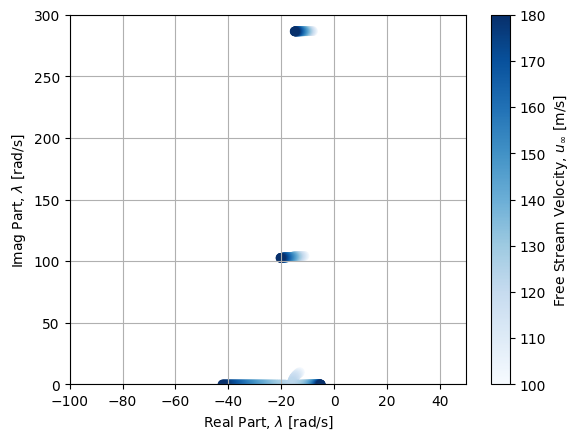

In [33]:
file_name = './output/%s/stability/velocity_analysis_min1000_max1800_nvel0081.dat' % case_name

velocity_analysis = np.loadtxt(file_name)
u_inf = velocity_analysis[:, 0]
eigs_r = velocity_analysis[:, 1]
eigs_i = velocity_analysis[:, 2]

fig = plt.figure()
plt.scatter(eigs_r, eigs_i, c=u_inf, cmap='Blues')
cbar = plt.colorbar()
cbar.set_label('Free Stream Velocity, $u_\infty$ [m/s]')

plt.grid()
plt.xlim(-100, 50)
plt.ylim(0, 300)
plt.xlabel('Real Part, $\lambda$ [rad/s]')
plt.ylabel('Imag Part, $\lambda$ [rad/s]');

[-0.79403448 -0.79403448 -0.80278067 -0.80278067 -0.81155278 -0.81155278 -0.82035117 -0.82035117 -0.82917616
 -0.82917616 -0.83802833 -0.83802833 -0.84690783 -0.84690783 -0.8558152  -0.8558152  -0.86475077 -0.86475077
 -0.87371505 -0.87371505 -0.88270835 -0.88270835 -0.89173114 -0.89173114 -0.9007839  -0.9007839  -0.90986697
 -0.90986697 -0.91898071 -0.91898071 -0.92812576 -0.92812576 -0.93730222 -0.93730222 -0.94651106 -0.94651106
 -0.95575234 -0.95575234 -0.96502674 -0.96502674 -0.97433452 -0.97433452 -0.98367626 -0.98367626 -0.99305248
 -0.99305248 -1.         -1.         -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1

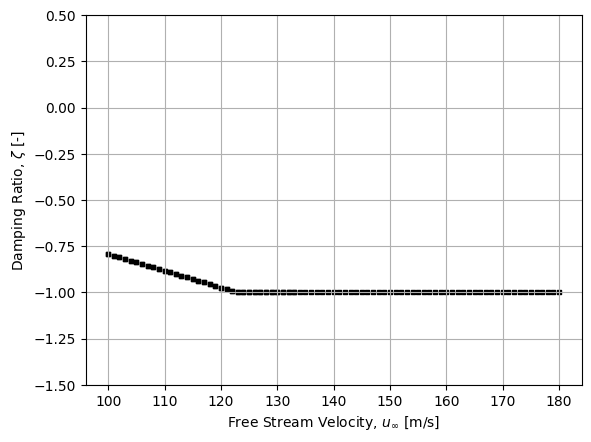

In [34]:
fig = plt.figure()
natural_frequency = np.sqrt(eigs_r ** 2 + eigs_i ** 2)
damping_ratio = eigs_r / natural_frequency
cond = (eigs_r>-25) * (eigs_r<10) * (natural_frequency<100) # filter unwanted eigenvalues for this plot (mostly aero modes)

plt.scatter(u_inf[cond], damping_ratio[cond], color='k', marker='s', s=9)
print(damping_ratio[cond])

plt.grid()
plt.ylim(-1.5, 0.5)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Damping Ratio, $\zeta$ [-]');

[510.07898193 510.07898193 286.89025013 286.89025013 104.89543444 104.89543444  16.35211653  16.35211653 510.080198
 510.080198   286.89326491 286.89326491 104.89450158 104.89450158  16.33758691  16.33758691 510.08137366 510.08137366
 286.89621205 286.89621205 104.89350426 104.89350426  16.32289595  16.32289595 510.08251036 510.08251036 286.89909238
 286.89909238 104.89244419 104.89244419  16.30804378  16.30804378 510.08360964 510.08360964 286.90190664 286.90190664
 104.89132278 104.89132278  16.29303089  16.29303089 510.08467283 510.08467283 286.9046557  286.9046557  104.89014065
 104.89014065  16.27785316  16.27785316 510.08570114 510.08570114 286.90734051 286.90734051 104.88889935 104.88889935
  16.26251461  16.26251461 510.08669599 510.08669599 286.90996168 286.90996168 104.88760029 104.88760029  16.24701228
  16.24701228 510.08765831 510.08765831 286.91252033 286.91252033 104.88624442 104.88624442  16.23134673  16.23134673
 510.08858936 510.08858936 286.91501701 286.91501701 104.8

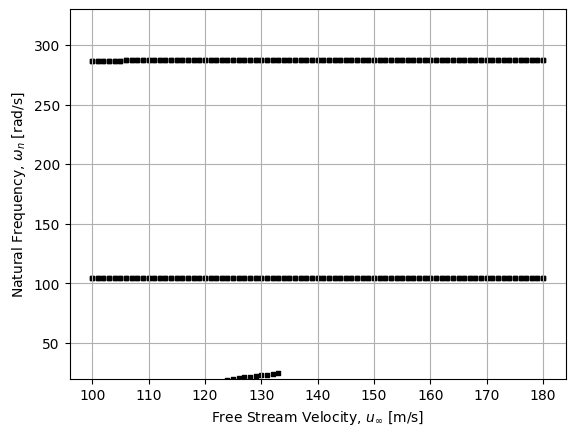

In [35]:
fig = plt.figure()
cond = (eigs_r>-25) * (eigs_r<10) # filter unwanted eigenvalues for this plot (mostly aero modes)
plt.scatter(u_inf[cond], natural_frequency[cond], color='k', marker='s', s=9)

print(natural_frequency[cond])

plt.grid()
plt.ylim(20, 330)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Natural Frequency, $\omega_n$ [rad/s]');